# Developer Productivity Agent

**Autonomous developer assistant built with LangGraph** — manages tasks, analyzes GitHub repos, estimates task complexity, and delivers daily briefings with deadline alerts.

## What it does
-  **Task management** — add, list, complete, and delete tasks with deadlines and time estimates
-  **GitHub integration** — fetch open issues, recent commits, and repo stats (public repos, no auth needed)
-  **Web research** — DuckDuckGo search for blocker solutions and task time estimation
-  **Email notifications** — Gmail SMTP deadline reminders with human-in-the-loop approval
-  **Multi-turn memory** — remembers context across an entire conversation via `MemorySaver`
-  **Human-in-the-loop** — `interrupt()` before sending emails or deleting tasks

## External Services Used
 **GitHub REST API** 
 
 **DuckDuckGo Search** 
 
 **Gmail SMTP**


In [1]:
!pip install -q \
langchain \
langchain-openai \
langgraph \
langchain-community \
openai \
ddgs


[notice] A new release of pip is available: 26.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import os
from getpass import getpass

try:
    from google.colab import userdata
    os.environ["OPENAI_API_KEY"] = userdata.get("OPENROUTER_API_KEY")
except Exception:
    if not os.environ.get("OPENAI_API_KEY"):
        os.environ["OPENAI_API_KEY"] = getpass("Paste OPENROUTER_API_KEY: ").strip()

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="openai/gpt-oss-120b:free",
    base_url="https://openrouter.ai/api/v1",
    temperature=0,
    max_tokens=2048,
)

print("LLM ready:", llm.model_name)

Paste OPENROUTER_API_KEY:  ········


LLM ready: openai/gpt-oss-120b:free


In [3]:
import json
import smtplib
import requests
from datetime import date, datetime
from email.mime.text import MIMEText
from typing import Annotated, Literal, Optional

from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage
from langchain_core.tools import tool
from langchain_community.tools import DuckDuckGoSearchRun
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
from langgraph.errors import GraphInterrupt
from pydantic import BaseModel, Field
from typing import TypedDict


print("All imports OK")

All imports OK


In [4]:
TASKS: dict[str, dict] = {}
_task_counter = 0


def _next_id() -> str:
    global _task_counter
    _task_counter += 1
    return f"task_{_task_counter:03d}"


class TaskEstimate(BaseModel):
    task_title: str = Field(description="Title of the task")
    
    estimated_hours: float = Field(description="Estimated hours to complete")
    complexity: Literal["low", "medium", "high"] = Field(description="Task complexity")
    reasoning: str = Field(description="Why this estimate was given")

    suggested_breakdown: list[str]= Field(description="Step-by-step subtasks")


print("Task store and Pydantic model ready")

Task store and Pydantic model ready


---
## Tools

In [5]:
@tool
def add_task(
    title: str,
    description: str,
    deadline: Optional[str] = None,
    repo: Optional[str] = None,
    estimated_hours: Optional[float] = None,
) -> str:
    """Add a new task to the task tracker.

    If estimated_hours is missing, estimate it before saving the task.
    """
    estimate_text = ""
    if estimated_hours is None:
        estimate, fallback = estimate_task_details(title, description, repo, use_web=False)
        if estimate:
            estimated_hours = estimate.estimated_hours
            estimate_text = (
                f"\nEstimated time: {estimate.estimated_hours}h\n"
                f"Complexity: {estimate.complexity}\n"
                f"Reasoning: {estimate.reasoning}\n"
                f"Breakdown:\n"
                + "\n".join(f"- {step}" for step in estimate.suggested_breakdown)
            )
        elif fallback:
            estimate_text = f"\nEstimate note:\n{fallback}"

    task_id = _next_id()
    TASKS[task_id] = {
        "id": task_id,
        "title": title,
        "description": description,
        "deadline": deadline,
        "repo": repo,
        "estimated_hours": estimated_hours,
        "actual_hours": None,
        "status": "pending",
        "created_at": date.today().isoformat(),
    }
    due = f" (due {deadline})" if deadline else ""
    estimate_suffix = f" | est: {estimated_hours}h" if estimated_hours else ""
    return f"Task added: [{task_id}] {title}{due}{estimate_suffix}{estimate_text}"
        
@tool
def list_tasks(status_filter: Optional[str] = None) -> str:
    """List all tasks with full details (status, description, deadline, repo, 
       estimated hours, actual hours, created and completed dates).
       Optionally filter by status: 'pending' or 'done'."""
    tasks = list(TASKS.values())
    if status_filter:
        tasks = [t for t in tasks if t["status"] == status_filter]
    if not tasks:
        return "No tasks found."
    lines = []
    for t in tasks:
        lines.append(
            f"[{t['id']}] {t['title']}\n"
            f"  Status       : {t['status'].upper()}\n"
            f"  Description  : {t['description']}\n"
            f"  Deadline     : {t['deadline'] or 'none'}\n"
            f"  Repo         : {t['repo'] or 'none'}\n"
            f"  Est. hours   : {t['estimated_hours'] or 'not estimated'}\n"
            f"  Actual hours : {t['actual_hours'] or 'not recorded'}\n"
            f"  Created      : {t['created_at']}\n"
            f"  Completed    : {t.get('completed_at', 'not yet')}\n"
        )
    return "\n".join(lines)


 
@tool
def complete_task(task_id: str, actual_hours: Optional[float] = None) -> str:
    """Mark a task as done and optionally record how long it actually took.
 
    Args:
        task_id: The task ID (e.g. 'task_001').
        actual_hours: How many hours it actually took. Optional.
    """
    if task_id not in TASKS:
        return f"Task {task_id} not found."
    TASKS[task_id]["status"] = "done"
    TASKS[task_id]["actual_hours"] = actual_hours
    TASKS[task_id]["completed_at"] = date.today().isoformat()
    msg = f"Marked {task_id} ('{TASKS[task_id]['title']}') as done."
    if actual_hours is not None and TASKS[task_id]["estimated_hours"]:
        diff = actual_hours - TASKS[task_id]["estimated_hours"]
        direction = "over" if diff > 0 else "under"
        msg += f" Took {actual_hours}h ({abs(diff):.1f}h {direction} estimate)."
    return msg
 
 
@tool
def delete_task(task_id: str) -> str:
    """Permanently delete a task. This is irreversible — human approval is required.
 
    Args:
        task_id: The task ID to delete (e.g. 'task_001').
    """
    if task_id not in TASKS:
        return f"Task {task_id} not found."
    task_title = TASKS[task_id]["title"]

    approval = interrupt(
        f"  DELETE TASK\n"
        f"  ID: {task_id}\n"
        f"  Title: {task_title}\n"
        f"This is permanent. Type 'yes' to confirm or anything else to cancel."
    )
    if str(approval).strip().lower() == "yes":
        del TASKS[task_id]
        return f" Task {task_id} ('{task_title}') deleted."
    else:
        return f"Deletion of {task_id} cancelled by user."
 
 
@tool
def check_deadlines() -> str:
    """Check which tasks are due today or overdue. Returns a summary."""
    today = date.today().isoformat()
    due_today, overdue = [], []
    for t in TASKS.values():
        if t["status"] == "done" or not t["deadline"]:
            continue
        if t["deadline"] == today:
            due_today.append(t)
        elif t["deadline"] < today:
            overdue.append(t)
    lines = []
    if due_today:
        lines.append("Due TODAY:")
        for t in due_today:
            lines.append(f"  - [{t['id']}] {t['title']}")
    if overdue:
        lines.append("OVERDUE:")
        for t in overdue:
            lines.append(f"  - [{t['id']}] {t['title']} (was due {t['deadline']})")
    if not lines:
        return "No tasks due today or overdue."
    return "\n".join(lines)
 
print("Task management tools ready")

Task management tools ready


In [6]:
GITHUB_HEADERS = {"Accept": "application/vnd.github+json"}


@tool
def get_github_repo_info(owner: str, repo: str) -> str:
    """Fetch general info about a public GitHub repository (stars, language, open issues count).

    Args:
        owner: GitHub username or org (e.g. 'anthropics').
        repo: Repository name (e.g. 'anthropic-sdk-python').
    """
    try:
        r = requests.get(
            f"https://api.github.com/repos/{owner}/{repo}",
            headers=GITHUB_HEADERS,
            timeout=10,
        )
        if r.status_code == 404:
            return f"Repository {owner}/{repo} not found."
        d = r.json()
        return (
            f"Repo: {d['full_name']}\n"
            f"Description: {d.get('description', 'N/A')}\n"
            f"Language: {d.get('language', 'N/A')}\n"
            f"Stars: {d.get('stargazers_count', 0):,}\n"
            f"Open issues: {d.get('open_issues_count', 0)}\n"
            f"Last pushed: {d.get('pushed_at', 'N/A')[:10]}"
        )
    except Exception as e:
        return f"GitHub API error: {e}"


@tool
def get_github_issues(owner: str, repo: str, max_results: int = 5) -> str:
    """Fetch the most recent open issues from a public GitHub repository.

    Args:
        owner: GitHub username or org.
        repo: Repository name.
        max_results: How many issues to return (default 5, max 10).
    """
    try:
        r = requests.get(
            f"https://api.github.com/repos/{owner}/{repo}/issues",
            headers=GITHUB_HEADERS,
            params={"state": "open", "per_page": min(max_results, 10)},
            timeout=10,
        )
        issues = r.json()
        if not issues or isinstance(issues, dict):
            return f"No open issues found for {owner}/{repo}."
        lines = [f"Open issues in {owner}/{repo}:"]
        for i in issues:
            lines.append(f"  #{i['number']}: {i['title']} ({i.get('comments', 0)} comments)")
        return "\n".join(lines)
    except Exception as e:
        return f"GitHub API error: {e}"


@tool
def get_github_recent_commits(owner: str, repo: str, max_results: int = 5) -> str:
    """Fetch the most recent commits from a public GitHub repository.

    Args:
        owner: GitHub username or org.
        repo: Repository name.
        max_results: How many commits to return (default 5).
    """
    try:
        r = requests.get(
            f"https://api.github.com/repos/{owner}/{repo}/commits",
            headers=GITHUB_HEADERS,
            params={"per_page": min(max_results, 10)},
            timeout=10,
        )
        commits = r.json()
        if not commits or isinstance(commits, dict):
            return f"No commits found for {owner}/{repo}."
        lines = [f"Recent commits in {owner}/{repo}:"]
        for c in commits:
            msg = c["commit"]["message"].split("\n")[0][:80]
            author = c["commit"]["author"]["name"]
            date_str = c["commit"]["author"]["date"][:10]
            lines.append(f"  [{date_str}] {author}: {msg}")
        return "\n".join(lines)
    except Exception as e:
        return f"GitHub API error: {e}"


print("GitHub tools ready")

GitHub tools ready


In [7]:
_ddg = DuckDuckGoSearchRun()


@tool
def search_web(query: str) -> str:
    """Search the web using DuckDuckGo. Use for:
    - Researching how long a task typically takes
    - Finding solutions to technical blockers
    - Looking up docs or best practices

    Args:
        query: Search query string.
    """
    try:
        result = _ddg.run(query)
        return result[:2000] 
    except Exception as e:
        return f"Search error: {e}"


print("Web search tool ready")

Web search tool ready


In [8]:
from langchain_openai import ChatOpenAI

_estimator_llm = ChatOpenAI(
    model="openai/gpt-oss-120b:free",
    base_url="https://openrouter.ai/api/v1",
    temperature=0,
    max_tokens=1500,
).with_structured_output(TaskEstimate)


@tool
def estimate_task(title: str, description: str, repo: Optional[str] = None) -> str:
    """Estimate how long a task will take based on its description and web research."""
    web_context = ""
    try:
        web_context = _ddg.run(f"how long does it take to {title} programming")[:1000]
    except Exception:
        pass

    repo_context = ""
    if repo:
        try:
            owner, repo_name = repo.split("/", 1)
            r = requests.get(
                f"https://api.github.com/repos/{owner}/{repo_name}",
                headers=GITHUB_HEADERS, timeout=10,
            )
            d = r.json()
            repo_context = (
                f"\nRepo context: {d.get('language', 'unknown')} project, "
                f"{d.get('size', 0)} KB, "
                f"{d.get('open_issues_count', 0)} open issues."
            )
        except Exception:
            pass

    prompt = (
        f"Task: {title}\n"
        f"Description: {description}{repo_context}\n\n"
        f"Web research context:\n{web_context}\n\n"
        f"Provide a realistic time estimate for a mid-level developer."
    )


    try:
        estimate: TaskEstimate = _estimator_llm.invoke(prompt)
        return (
            f" Task Estimate: {estimate.task_title}\n"
            f"  Estimated time: {estimate.estimated_hours}h\n"
            f"  Complexity: {estimate.complexity}\n"
            f"  Reasoning: {estimate.reasoning}\n"
            f"  Breakdown:\n"
            + "\n".join(f"    - {step}" for step in estimate.suggested_breakdown)
        )
    except Exception:
        fallback = llm.invoke(prompt)
        return f" Task Estimate (plain):\n{fallback.content}"

print("Task estimation tool ready")

Task estimation tool ready


In [9]:
@tool
def update_task(
    task_id: Optional[str] = None,
    title_contains: Optional[str] = None,
    title: Optional[str] = None,
    description: Optional[str] = None,
    deadline: Optional[str] = None,
    repo: Optional[str] = None,
    estimated_hours: Optional[float] = None,
    status: Optional[Literal["pending", "done"]] = None,
) -> str:
    """Update an existing task.
    Args:
        task_id: Exact task ID, such as task_001. Use this when available.
        title_contains: Part of the task title to search for when task_id is unknown.
        title: New task title. Optional.
        description: New task description. Optional.
        deadline: New due date in YYYY-MM-DD format. Optional.
        repo: GitHub repo in owner/repo format. Optional.
        estimated_hours: New estimated hours. Optional.
        status: New status, either pending or done. Optional.
    """
    matched_task = None
    if task_id:
        matched_task = TASKS.get(task_id)
    elif title_contains:
        search_text = title_contains.lower()
        matches = [t for t in TASKS.values() if search_text in t["title"].lower()]
        if len(matches) > 1:
            return "Multiple tasks matched. Please specify the task ID:\n" + "\n".join(
                f"- [{t['id']}] {t['title']}" for t in matches
            )
        if matches:
            matched_task = matches[0]
    if not matched_task:
        return "Task not found. Ask to list tasks, then update using the task ID."
    if title is not None:
        matched_task["title"] = title
    if description is not None:
        matched_task["description"] = description
    if deadline is not None:
        matched_task["deadline"] = deadline
    if repo is not None:
        matched_task["repo"] = repo
    if estimated_hours is not None:
        matched_task["estimated_hours"] = estimated_hours
    if status is not None:
        matched_task["status"] = status
        if status == "done":
            matched_task["completed_at"] = date.today().isoformat()
    deadline_text = f" | due: {matched_task['deadline']}" if matched_task["deadline"] else ""
    repo_text = f" | repo: {matched_task['repo']}" if matched_task["repo"] else ""
    estimate_text = f" | est: {matched_task['estimated_hours']}h" if matched_task["estimated_hours"] else ""
    return (
        f"Updated [{matched_task['id']}] {matched_task['title']}"
        f"{deadline_text}{repo_text}{estimate_text}"
    )

In [10]:
GMAIL_USER = os.environ.get("GMAIL_USER", "")      
GMAIL_APP_PASSWORD = os.environ.get("GMAIL_APP_PASSWORD", "")


@tool
def send_deadline_email(to_email: str, task_ids: str) -> str:
    """Send a deadline reminder email for the specified tasks.
    This is a destructive/irreversible action — human approval is required.

    Args:
        to_email: Recipient email address.
        task_ids: Comma-separated task IDs to include in the reminder (e.g. 'task_001,task_002').
    """
    ids = [t.strip() for t in task_ids.split(",")]
    tasks_to_notify = [TASKS[tid] for tid in ids if tid in TASKS]

    if not tasks_to_notify:
        return "No valid tasks found for those IDs."

    task_list = "\n".join(
        f"  - {t['title']} (due: {t['deadline'] or 'no deadline'})" for t in tasks_to_notify
    )
    subject = f"⏰ Deadline Reminder — {len(tasks_to_notify)} task(s) due"
    body = f"Hi,\n\nYou have the following task(s) due today or soon:\n{task_list}\n\nGood luck!\n"

   
    approval = interrupt(
        f"  SEND EMAIL\n"
        f"  To: {to_email}\n"
        f"  Subject: {subject}\n"
        f"  Tasks:\n{task_list}\n"
        f"Type 'yes' to send or anything else to cancel."
    )

    if str(approval).strip().lower() != "yes":
        return " Email cancelled by user."

    if GMAIL_USER and GMAIL_APP_PASSWORD:
        try:
            msg = MIMEText(body)
            msg["Subject"] = subject
            msg["From"] = GMAIL_USER
            msg["To"] = to_email
            with smtplib.SMTP_SSL("smtp.gmail.com", 465) as server:
                server.login(GMAIL_USER, GMAIL_APP_PASSWORD)
                server.sendmail(GMAIL_USER, to_email, msg.as_string())
            return f" Email sent to {to_email}."
        except Exception as e:
            return f"Email error: {e}"
    else:
        return (
            f" [DRY RUN] Email would be sent to {to_email}:\n"
            f"  Subject: {subject}\n"
            f"  Body: {body}\n"
            f"  (Set GMAIL_USER and GMAIL_APP_PASSWORD env vars to send real emails.)"
        )


@tool
def daily_briefing() -> str:
    """Generate a morning daily briefing — deadlines, task summary, and recommendations.
    Call this at the start of the day for an overview of what to work on.
    """
    today = date.today().isoformat()
    pending = [t for t in TASKS.values() if t["status"] == "pending"]
    done_today = [t for t in TASKS.values() if t["status"] == "done" and t.get("completed_at") == today]
    due_today = [t for t in pending if t["deadline"] == today]
    overdue = [t for t in pending if t["deadline"] and t["deadline"] < today]

    total_estimated = sum(t["estimated_hours"] or 0 for t in pending)

    lines = [
        f" Daily Briefing — {today}",
        f"━━━━━━━━━━━━━━━━━━━━━━━",
        f" Summary: {len(pending)} pending task(s), {len(done_today)} completed today",
        f"  Total estimated work: {total_estimated:.1f}h",
    ]
    if overdue:
        lines.append(f"\n OVERDUE ({len(overdue)}):")
        for t in overdue:
            lines.append(f"  - [{t['id']}] {t['title']} (was due {t['deadline']})")
    if due_today:
        lines.append(f"\n DUE TODAY ({len(due_today)}):")
        for t in due_today:
            est = f" | est. {t['estimated_hours']}h" if t["estimated_hours"] else ""
            lines.append(f"  - [{t['id']}] {t['title']}{est}")
    if pending:
        lines.append(f"\n ALL PENDING TASKS:")
        for t in sorted(pending, key=lambda x: x["deadline"] or "9999"):
            deadline_str = f" | due: {t['deadline']}" if t["deadline"] else ""
            est_str = f" | est: {t['estimated_hours']}h" if t["estimated_hours"] else ""
            lines.append(f"  - [{t['id']}] {t['title']}{deadline_str}{est_str}")
    if not pending:
        lines.append("\n No pending tasks — great job!")
    return "\n".join(lines)


print("Email and briefing tools ready")

Email and briefing tools ready


---
## Graph


In [11]:

class AgentState(TypedDict):
    messages: Annotated[list, add_messages]



all_tools = [
    add_task,
    list_tasks,
    complete_task,
    delete_task,
    check_deadlines,
    get_github_repo_info,
    get_github_issues,
    get_github_recent_commits,
    search_web,
    estimate_task,
    send_deadline_email,
    daily_briefing,
    update_task
]


llm_with_tools = llm.bind_tools(all_tools)

print(f"{len(all_tools)} tools registered: {[t.name for t in all_tools]}")

13 tools registered: ['add_task', 'list_tasks', 'complete_task', 'delete_task', 'check_deadlines', 'get_github_repo_info', 'get_github_issues', 'get_github_recent_commits', 'search_web', 'estimate_task', 'send_deadline_email', 'daily_briefing', 'update_task']


In [12]:
SYSTEM_PROMPT = """You are an intelligent Developer Productivity Agent.
Respond in 5 short bullet points or fewer. Avoid tables.

CRITICAL RULES — follow these always:
- When the user asks to add a task, ALWAYS call add_task tool immediately. Never just describe what you would do.
- When the user asks to add a task, ALWAYS call estimate_task tool right after add_task. Never estimate from memory.
- When the user asks about a GitHub repo, ALWAYS call the GitHub tools.
- When the user asks for a briefing, ALWAYS call daily_briefing tool.
- When the user asks to search or research anything, ALWAYS call search_web tool.
- NEVER answer from your own knowledge when a tool exists for the task.

You can:
- Manage tasks (add, list, complete, delete) with deadlines and estimates
- Analyze GitHub repos to track issues and recent activity  
- Research blockers and estimate task effort using web search
- Send deadline reminder emails (always ask for confirmation first)
- Generate daily briefings

Be concise and practical — developers are busy.
"""

print("System prompt set")

System prompt set


In [13]:
from langgraph.prebuilt import ToolNode

def agent_node(state: AgentState) -> dict:
    messages = [SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}


def should_continue(state: AgentState) -> Literal["tools", "__end__"]:
    last = state["messages"][-1]
    if hasattr(last, "tool_calls") and last.tool_calls:
        return "tools"
    return "__end__"

print("Nodes defined")

Nodes defined


In [14]:

memory = MemorySaver() 

builder = StateGraph(AgentState)
builder.add_node("agent", agent_node)
builder.add_node("tools", ToolNode(all_tools))

builder.add_edge(START, "agent")
builder.add_conditional_edges("agent", should_continue)
builder.add_edge("tools", "agent")

agent = builder.compile(checkpointer=memory, interrupt_before=["tools"])


print("Agent compiled with MemorySaver")

Agent compiled with MemorySaver


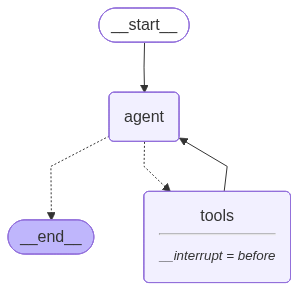

In [15]:

from IPython.display import Image
Image(agent.get_graph().draw_mermaid_png())

---
## Helper Functions


In [16]:
def run(user_message: str, thread_id: str = "default", verbose: bool = True) -> str:
    """Run the agent with a user message. Returns the final response text."""
    config = {"configurable": {"thread_id": thread_id}}
    result = agent.invoke(
        {"messages": [HumanMessage(content=user_message)]},
        config=config,
    )
    state = agent.get_state(config)
    if state.next:
        interrupt_val = None
        for task in state.tasks:
            if hasattr(task, 'interrupts') and task.interrupts:
                interrupt_val = task.interrupts[0].value
                break
        if interrupt_val:
            print("\n" + "="*60)
            print(" AGENT PAUSED — HUMAN APPROVAL REQUIRED")
            print("="*60)
            print(interrupt_val)
            print("="*60)
            print(f"Use run_with_approval('{thread_id}', 'yes') to approve")  
            print(f"Use run_with_approval('{thread_id}', 'no') to cancel")   
            return "[PAUSED - waiting for approval]"

    last_msg = result["messages"][-1]
    if verbose:
        content = getattr(last_msg, "content", "") or "" 
        if content:
            print(f"\n Agent: {content}")
    return last_msg.content


def run_with_approval(thread_id: str, approval: str) -> str:
    """Resume a paused agent after an interrupt with the user's approval response.

    Args:
        thread_id: The thread that is paused.
        approval: 'yes' to approve, anything else to cancel.
    """
    config = {"configurable": {"thread_id": thread_id}}
    result = agent.invoke(
        Command(resume=approval),
        config=config,
    )

    state = agent.get_state(config)
    if state.next:
        interrupt_val = None
        for task in state.tasks:
            if hasattr(task, 'interrupts') and task.interrupts:
                interrupt_val = task.interrupts[0].value
                break
        if interrupt_val:
            print("\n" + "="*60)
            print(" AGENT PAUSED AGAIN — ADDITIONAL APPROVAL REQUIRED")
            print("="*60)
            print(interrupt_val)
            print("="*60)
            print(f"Use run_with_approval('{thread_id}', 'yes') to approve")
            print(f"Use run_with_approval('{thread_id}', 'no') to cancel")
            return "[PAUSED - waiting for approval]"

    last_msg = result["messages"][-1]
    content = getattr(last_msg, "content", "") or "" 
    if content:
        print(f"\n Agent: {content}")
    return last_msg.content

    
def estimate_task_details(
    title: str,
    description: str,
    repo: Optional[str] = None,
    use_web: bool = True,
) -> tuple[Optional[TaskEstimate], str]:
    web_context = ""
    if use_web:
        try:
            web_context = _ddg.run(f"how long does it take to {title} programming")[:1000]
        except Exception:
            web_context = "No web context available."

    repo_context = ""
    if repo:
        try:
            owner, repo_name = repo.split("/", 1)
            response = requests.get(
                f"https://api.github.com/repos/{owner}/{repo_name}",
                headers=GITHUB_HEADERS,
                timeout=10,
            )
            data = response.json()
            repo_context = (
                f"\nRepo context: {data.get('language', 'unknown')} project, "
                f"{data.get('size', 0)} KB, {data.get('open_issues_count', 0)} open issues."
            )
        except Exception:
            pass

    prompt = (
        f"Task: {title}\n"
        f"Description: {description}{repo_context}\n\n"
        f"Web research context:\n{web_context}\n\n"
        f"Provide a realistic time estimate for a mid-level developer."
    )

    try:
        return _estimator_llm.invoke(prompt), "" 
    except Exception as exc:
        return None, f"Estimate skipped: {exc}"

print("Helper functions ready")

Helper functions ready



## Tests

In [17]:
TASKS.clear()
_task_counter = 0
print("Task store reset")

Task store reset


In [18]:
print("=" * 60)
print("QUERY 1: Task creation with time estimation")
print("=" * 60)

run(
    "Add a task to implement JWT authentication for my Flask app. ",
    thread_id="demo"
);

QUERY 1: Task creation with time estimation


In [19]:
print("=" * 60)
print("QUERY 2: GitHub repo analysis")
print("=" * 60)

TASKS["task_002"] = {
    "id": "task_002", "title": "Write API documentation",
    "description": "Document all endpoints", "deadline": "2026-11-30",
    "repo": "anthropics/anthropic-sdk-python", "estimated_hours": 3.0,
    "actual_hours": None, "status": "pending", "created_at": "2026-05-13"
}

_task_counter = max(_task_counter, 2)

run(
    "Show me the open issues and recent commits for the repo anthropics/anthropic-sdk-python. "
    "Do I have any tasks linked to this repo?",
    thread_id="demo"
);

QUERY 2: GitHub repo analysis


In [20]:
print("=" * 60)
print("QUERY 3: Suggest next task for my GitHub project")
print("=" * 60)

run(
    "Analyze the repo MariamiKakh/Dev-productivity-agent. "
    "Look at open issues and recent commits, then suggest the single best next task "
    "I should add. Give it a short title, description, and an estimated time.",
    thread_id="demo"
);

QUERY 3: Suggest next task for my GitHub project


In [21]:
print("=" * 60)
print("QUERY 4: Daily briefing")
print("=" * 60)

run(
    "Give me my daily briefing. What do I have to work on today?",
    thread_id="demo"
);

QUERY 4: Daily briefing


In [22]:
print("=" * 60)
print("QUERY 5: Mark task as done and check remaining work")
print("=" * 60)

run(
    "I just finished the API documentation task (task_002). It took me 4 hours. "
    "Mark it as done and then show me all my remaining pending tasks.",
    thread_id="demo"
);

QUERY 5: Mark task as done and check remaining work


In [23]:
today = date.today().isoformat()
TASKS["task_urgent"] = {
    "id": "task_urgent",
    "title": "Deploy hotfix to production",
    "description": "Critical security patch",
    "deadline": today,
    "repo": None,
    "estimated_hours": 1.0,
    "actual_hours": None,
    "status": "pending",
    "created_at": today,
}

print(f"Added urgent task due today ({today})")

APPROVAL_THREAD = "approval-demo-v2"

Added urgent task due today (2026-05-13)


In [24]:
print("=" * 60)
print("DESTRUCTIVE ACTION - SEND EMAIL (will pause for approval)")
print("=" * 60)

run(
    "Send me a deadline reminder email to developer@example.com for the task task_urgent.",
    thread_id=APPROVAL_THREAD
)

DESTRUCTIVE ACTION - SEND EMAIL (will pause for approval)

 Agent: - I see you want a deadline reminder email to **developer@example.com** for task **task_urgent**.  
- Sending this email is irreversible and requires your explicit confirmation.  
- Please confirm you’d like me to proceed (yes/no).


'- I see you want a deadline reminder email to **developer@example.com** for task **task_urgent**.  \n- Sending this email is irreversible and requires your explicit confirmation.  \n- Please confirm you’d like me to proceed (yes/no).'

In [25]:
print("=" * 60)
print("USER APPROVES — resuming with 'yes'")
print("=" * 60)

run_with_approval(APPROVAL_THREAD, "yes")

USER APPROVES — resuming with 'yes'

 Agent: - I see you want a deadline reminder email to **developer@example.com** for task **task_urgent**.  
- Sending this email is irreversible and requires your explicit confirmation.  
- Please confirm you’d like me to proceed (yes/no).


'- I see you want a deadline reminder email to **developer@example.com** for task **task_urgent**.  \n- Sending this email is irreversible and requires your explicit confirmation.  \n- Please confirm you’d like me to proceed (yes/no).'

In [26]:
DENY_THREAD = "deny-demo"

TASKS["task_to_delete"] = {
    "id": "task_to_delete",
    "title": "Old refactor task",
    "description": "No longer needed",
    "deadline": None,
    "repo": None,
    "estimated_hours": None,
    "actual_hours": None,
    "status": "pending",
    "created_at": today,
}
print("Added task_to_delete for demo")

Added task_to_delete for demo


In [27]:
print("=" * 60)
print("DESTRUCTIVE ACTION - DELETE TASK (will pause for approval)")
print("=" * 60)

run(
    "Delete task_to_delete — I don't need it anymore.",
    thread_id=DENY_THREAD
)

DESTRUCTIVE ACTION - DELETE TASK (will pause for approval)


''

In [28]:
print("=" * 60)
print("USER CANCELS — resuming with 'no'")
print("=" * 60)

run_with_approval(DENY_THREAD, "no")

print(f"\nTask still in store: {'task_to_delete' in TASKS}")

USER CANCELS — resuming with 'no'

 Agent: - Task deletion was cancelled; let me know if you’d like to remove a different task or need anything else.

Task still in store: True


---
## Evaluation Table

| # | Query | Expected Behavior | Tools Used | Result |
|---|---|---|---|---|
| 1 | "Add a task to implement JWT authentication for my Flask app." | Calls `add_task` (and estimation), returns task ID + estimated hours. | `add_task`, `estimate_task`, `search_web` | passed |
| 2 | "Show open issues and recent commits for `anthropics/anthropic-sdk-python`. Do I have any tasks linked?" | Calls `get_github_issues`, `get_github_recent_commits`, `list_tasks`. | `get_github_issues`, `get_github_recent_commits`, `list_tasks` | passed |
| 3 | "Analyze `MariamiKakh/Dev-productivity-agent` — open issues + recent commits — and suggest the single best next task with title, description, estimated time." | Calls GitHub tools and `estimate_task`, returns a concrete next task suggestion with hours. | `get_github_repo_info`, `get_github_issues`, `get_github_recent_commits`, `estimate_task` | passed |
| 4 | "Give me my daily briefing. What do I have to work on today?" | Calls `daily_briefing`, lists overdue / due today / pending with estimates and a recommendation. | `daily_briefing`, `check_deadlines` | passed |
| 5 | "I finished task_002 in 4 hours. Mark it done and show remaining pending tasks." | Calls `complete_task` with `actual_hours`, then `list_tasks`. | `complete_task`, `list_tasks` | passed |
| 6 | "Use `send_deadline_email` to send a reminder to developer@example.com for task_urgent." → APPROVE | `send_deadline_email` fires `interrupt()`, resumes after `yes`, email sent in dry-run mode. | `send_deadline_email` + `interrupt()` | Partial | LLM asked for confirmation in text
| 7 | "Delete task_to_delete — I don't need it anymore." → DENY | `delete_task` fires `interrupt()`, resumes after `no`, task preserved. | `delete_task` + `interrupt()` | passed |
| 8 | Multi-turn memory across the same `thread_id`: tell name → add task → ask what was said earlier. | Recalls the name from turn 1 in turn 3 via `MemorySaver`. | `MemorySaver` |passed|
